# Block 7 — Hyperparameter Tuning with Optuna (Optional)

**Goals for this block:**

- Learn automated hyperparameter optimization with **Optuna**
- Tune a **Temporal Convolutional Network (TCN)** model
- Find optimal parameters for **TCN** with **future covariates**: calendar features (hour, day-of-week, month)
- Compare performance improvements through systematic tuning

## 0. Environment & Imports

In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
tf.config.set_logical_device_configuration(gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=6500)])

import torch
assert torch.cuda.is_available()
torch.cuda.set_per_process_memory_fraction(0.3)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from darts.dataprocessing.transformers import Scaler
from darts.utils.missing_values import fill_missing_values


## 2. Load & Prepare Data

Load the electricity consumption dataset and prepare it for time series forecasting.

In [2]:
from darts.datasets import ElectricityConsumptionZurichDataset

series = ElectricityConsumptionZurichDataset().load() 
target_columns = ["Value_NE5", "Value_NE7"]
covariate_columns = ['Hr [%Hr]', 'RainDur [min]', 'StrGlo [W/m2]', 'T [°C]', 'WD [°]', 'WVs [m/s]', 'WVv [m/s]', 'p [hPa]']

# splt the time series into target and covariates
target_series = series[target_columns]
past_covariates = series[covariate_columns]


<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Prepare data for training</h2>

1. Preprocess the dataset using our preprocessing pipeline
    - create now a train, **validation** and test sets


</div>

#### 2.1 Basic Preprocessing

Apply our standard preprocessing pipeline to the electricity data.

⚠️: We will be tuning a TCN model which takes past covariates. Think of preprocessing target and past covariate series

In [ ]:
# preprocess target series 70% train, 15% validation, 15% test
train_target, test_target = series.split_before(0.7)
val_target, test_target = test_target.split_before(0.5)

scaler_target = Scaler(MinMaxScaler())
train_scaled = scaler_target.fit_transform(train_target)
val_scaled = scaler_target.transform(val_target)
test_scaled = scaler_target.transform(test_target)

# preprocess covariate series
train_cov, test_cov = past_covariates.split_before(0.7)
val_cov, test_cov = test_cov.split_before(0.5)

scaler_cov = Scaler(MinMaxScaler())
train_cov_scaled = scaler_cov.fit_transform(train_cov)
val_cov_scaled = scaler_cov.transform(val_cov)
test_cov_scaled = scaler_cov.transform(test_cov)

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Hyperparameter Optimization with Optuna</h2>

Learn how to systematically find the best model configuration using Optuna's optimization framework.

1. Build the objective function that defines what to optimize

2. Run a tuning job to find optimal hyperparameters

This exercise will teach you automated hyperparameter optimization for time series models.

</div>

### 1. **Study**: The optimization session
```python
study = optuna.create_study(direction="minimize", study_name="LSTM_sMAPE")
```
- `direction`: "minimize" (for loss/error) or "maximize" (for accuracy)
- `study_name`: Identifier for tracking experiments

#### 2. **Trial**: Single hyperparameter configuration attempt
```python
def objective_lstm(trial):
    # Suggest hyperparameter values
    window_size = 24 * trial.suggest_int("window_size_factor", 1, 7)
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 96, 128])
    
    # Train model with suggested parameters
    model = RNNModel(input_chunk_length=window_size, hidden_dim=hidden_dim, ...)
    
    # Return metric to optimize
    return validation_error
```

#### 3. **Hyperparameter Suggestion Methods**

| Method | Use Case | Example |
|--------|----------|---------|
| `suggest_int(name, low, high)` | Integer ranges | `trial.suggest_int("layers", 1, 5)` |
| `suggest_float(name, low, high)` | Continuous values | `trial.suggest_float("lr", 1e-5, 1e-1, log=True)` |
| `suggest_categorical(name, choices)` | Discrete choices | `trial.suggest_categorical("optimizer", ["adam", "sgd"])` |
| `suggest_uniform(name, low, high)` | Uniform distribution | `trial.suggest_uniform("dropout", 0.1, 0.5)` |


### 3.2 TCN Objective Function
Define the objective function for optimizing our Temporal Convolutional Network.

In [4]:
# Fixed forecast horizon for all experiments
forecast_horizon = 24

Suggestion: TCN Hyperparameters to be tuned:

- `input_chunk_length`: How many past timesteps to use (4-10 days)
- `num_filters`: Number of convolutional filters (2, 4, 16)
- `kernel_size`: Size of convolutional kernels (3 to 11)
- `dilation_base`: Base for exponential dilation (2 to 4)

In [ ]:
from darts.models import TCNModel
from darts.metrics import smape

# 1. Build the objective function
def objective_tcn(trial):
    model = TCNModel(
                input_chunk_length=24 * trial.suggest_int("input_length_factor", 4, 10),
                output_chunk_length=forecast_horizon,
                num_filters=trial.suggest_categorical("num_filters", [2, 4, 16]),
                kernel_size=trial.suggest_int("kernel_size", 3, 11, step=2),
                dilation_base=trial.suggest_int("dilation_base", 2, 4),
                dropout=0.3,
                batch_size=256,
                pl_trainer_kwargs={"accelerator": "gpu"},
                random_state=42
            )

    # Train the model without using validation covariates
    model.fit(
        series=train_scaled, 
        past_covariates=train_cov_scaled,
        epochs=8,
        verbose=False)
    
    # Generate historical forecasts on validation set
    pred_series = model.historical_forecasts(series=val_scaled,
                                            past_covariates=val_cov_scaled,
                                            forecast_horizon=forecast_horizon, 
                                            retrain=False, 
                                            last_points_only=True)
    
    # Inverse transform predictions and targets
    pred_unscaled = scaler_target.inverse_transform(pred_series)

    # Calculate and return sMAPE
    smape_score = smape(pred_unscaled, val_target)
    return smape_score

The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


## 4. Running Optimization Studies

Execute the hyperparameter optimization and analyze results.

### 4.1 Optimize TCN Parameters

In [6]:
#########################
train_scaled = train_scaled.astype(np.float32)
val_scaled = val_scaled.astype(np.float32)
train_cov_scaled = train_cov_scaled.astype(np.float32)
val_cov_scaled = val_cov_scaled.astype(np.float32)
test_cov_scaled = test_cov_scaled.astype(np.float32)
test_scaled = test_scaled.astype(np.float32)

In [ ]:
import optuna

study_tcn = optuna.create_study(direction="minimize", study_name="TCN_SMAPE")
study_tcn.optimize(objective_tcn, n_trials=15, show_progress_bar=True)
print("Best TCN sMAPE:", round(study_tcn.best_value, 4))
print(study_tcn.best_trial.params)


[I 2025-12-01 22:55:47,546] A new study created in memory with name: TCN_SMAPE


  0%|          | 0/4 [00:00<?, ?it/s]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[I 2025-12-01 22:56:15,145] Trial 0 finished with value: 54.75790222276517 and parameters: {'input_length_factor': 9, 'num_filters': 2, 'kernel_size': 11, 'dilation_base': 4}. Best is trial 0 with value: 54.75790222276517.


/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[I 2025-12-01 22:56:36,668] Trial 1 finished with value: 53.30460184926032 and parameters: {'input_length_factor': 6, 'num_filters': 4, 'kernel_size': 3, 'dilation_base': 3}. Best is trial 1 with value: 53.30460184926032.


/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[I 2025-12-01 22:57:05,126] Trial 2 finished with value: 52.57723265940524 and parameters: {'input_length_factor': 9, 'num_filters': 4, 'kernel_size': 5, 'dilation_base': 3}. Best is trial 2 with value: 52.57723265940524.


/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[I 2025-12-01 22:57:32,917] Trial 3 finished with value: 48.29155687882089 and parameters: {'input_length_factor': 6, 'num_filters': 16, 'kernel_size': 3, 'dilation_base': 2}. Best is trial 3 with value: 48.29155687882089.
Best TCN sMAPE: 48.2916
{'input_length_factor': 6, 'num_filters': 16, 'kernel_size': 3, 'dilation_base': 2}


### 4.2 Analyze Optimization Results
Review all trials to understand hyperparameter impact on performance. 

`value`refers to the metric you choose to optimize (in this case sMAPE)

In [8]:
df_results = study_tcn.trials_dataframe().sort_values("value")
df_results.head(15)

,number,value,datetime_start,datetime_complete,duration,params_dilation_base,params_input_length_factor,params_kernel_size,params_num_filters,state
3,3,48.291557,2025-12-01 22:57:05.127149,2025-12-01 22:57:32.917921,0 days 00:00:27.790772,2,6,3,16,COMPLETE
2,2,52.577233,2025-12-01 22:56:36.668891,2025-12-01 22:57:05.126276,0 days 00:00:28.457385,3,9,5,4,COMPLETE
1,1,53.304602,2025-12-01 22:56:15.146300,2025-12-01 22:56:36.667992,0 days 00:00:21.521692,3,6,3,4,COMPLETE
0,0,54.757902,2025-12-01 22:55:47.562812,2025-12-01 22:56:15.145397,0 days 00:00:27.582585,4,9,11,2,COMPLETE


This table shows:

- value: Validation metric sMAPE (lower is better)

- params_*: Hyperparameter values for each trial

- Results sorted by performance (best first)

## 5. Final Evaluation on Test

Let's evaluate our best model and compare its performance with the TCN model from BLOCK 3

### 5.1 Train Best Model on Full Training Data


In [10]:
from darts.metrics import mae

# Rebuild the best model from the best trial
best_tcn = TCNModel(
            input_chunk_length=24 * study_tcn.best_trial.params["input_length_factor"],
            output_chunk_length=forecast_horizon,
            num_filters=study_tcn.best_trial.params["num_filters"],
            kernel_size=study_tcn.best_trial.params["kernel_size"],
            dilation_base=study_tcn.best_trial.params["dilation_base"],
            dropout=0.3,
            batch_size=256,
            pl_trainer_kwargs={"accelerator": "gpu"}
        )

# Combine train and validation for final training
trainval_scaled = train_scaled.append(val_scaled)
trainval_past_cov = train_cov_scaled.append(val_cov_scaled)

# Train final models on train+val data
best_tcn.fit(series=trainval_scaled, 
             past_covariates=trainval_past_cov,
             epochs=10,
             verbose=False)


# Make predictions on test set
pred_tcn = best_tcn.historical_forecasts(series=test_scaled, past_covariates=test_cov_scaled , 
                                         forecast_horizon=forecast_horizon, retrain=False, last_points_only=True)

# Inverse transform predictions and test data
pred_tcn_unscaled = scaler_target.inverse_transform(pred_tcn)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


### 5.2 Performance Analysis & Visualization


In [11]:
# Calculate MAE, RMSE, MAPE, sMAPE

from darts.metrics import mae, rmse, mape, smape

evaluation_metrics_tcn = {
    "MAE": mae(test_target, pred_tcn_unscaled),
    "RMSE": rmse(test_target, pred_tcn_unscaled),
    "MAPE": mape(test_target, pred_tcn_unscaled),
    "sMAPE": smape(test_target, pred_tcn_unscaled),
}
print(evaluation_metrics_tcn)

ValueError: `actual_series` must be strictly positive to compute the MAPE.


ValueError: `actual_series` must be strictly positive to compute the MAPE.

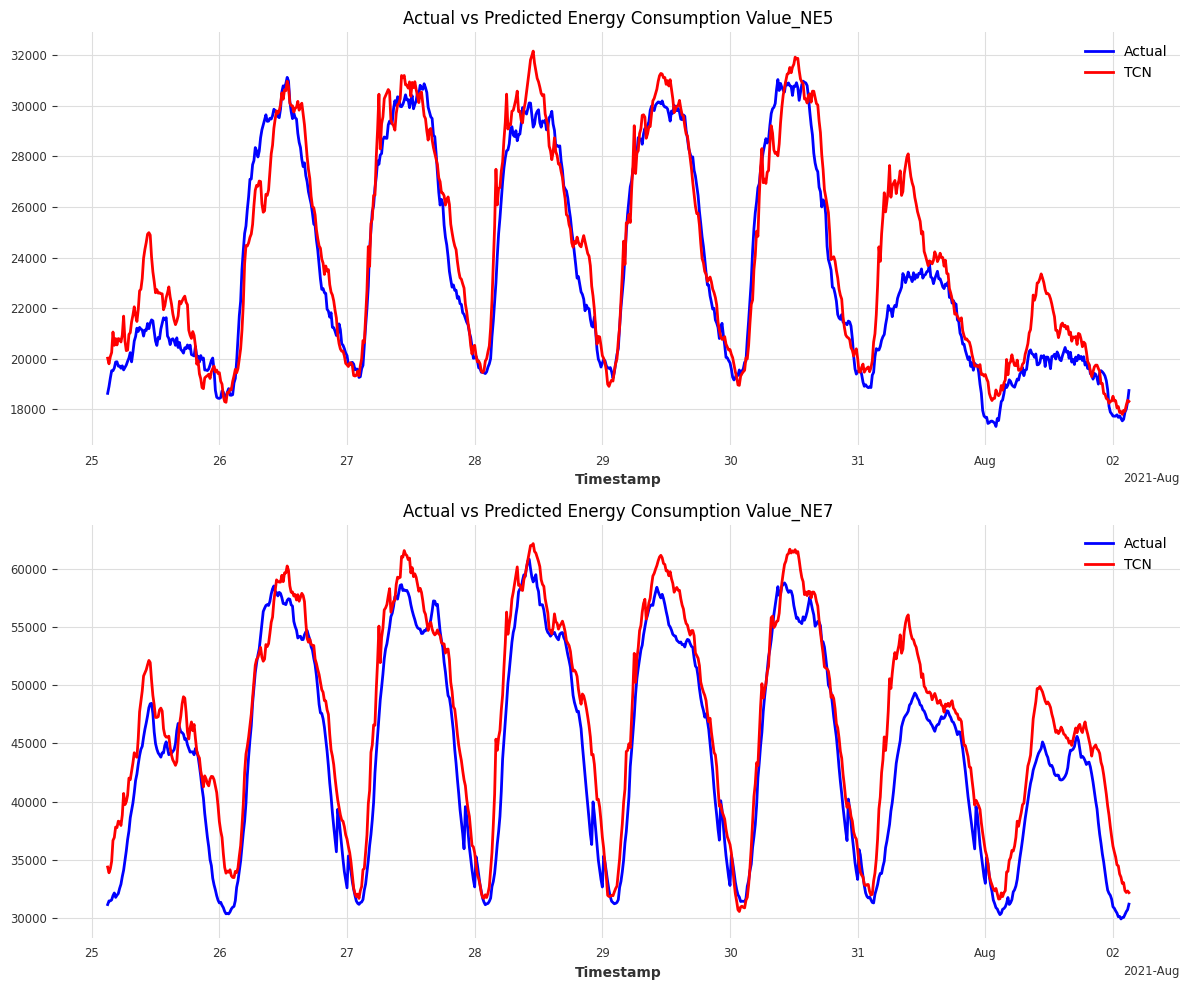

In [12]:
# Plotting some predictions vs actuals
start_idx = pd.Timestamp('2021-07-25 03:00:00')
end_idx = pd.Timestamp('2021-08-02 03:00:00')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
test_target[target_columns[0]][start_idx:end_idx].plot(label="Actual", color='blue', ax=ax1)
pred_tcn_unscaled[target_columns[0]][start_idx:end_idx].plot(label="TCN", color='red', title=f"Actual vs Predicted Energy Consumption {target_columns[0]}", ax=ax1)

test_target[target_columns[1]][start_idx:end_idx].plot(label="Actual", color='blue', ax=ax2)
pred_tcn_unscaled[target_columns[1]][start_idx:end_idx].plot(label="TCN", color='red', title=f"Actual vs Predicted Energy Consumption {target_columns[1]}", ax=ax2)

ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show()

## ✅ Summary

## What You've Accomplished:

- Automated Hyperparameter Optimization: Used Optuna to systematically find optimal model configurations

- TCN Model Tuning: Optimized Temporal Convolutional Network parameters for time series forecasting

- Performance Comparison: Evaluated improvements from systematic tuning vs. manual parameter selection
